In [13]:
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
import os
import numpy as np

os.chdir('/Users/sophiaye/Desktop/personal_projects/buses/demographic_insights')
print(os.getcwd())

/Users/sophiaye/Desktop/personal_projects/buses/demographic_insights


In [9]:
air_df = pd.read_csv('aqe-nta.csv')
index_df = pd.read_csv('bus_need_index_final_full.csv')
print(air_df.columns.tolist())
air_df.head(3)

['NTACODE', 'BORO', 'BoroCode', 'NTA_NAME', 'PM_Avg', 'PM_tertiles', 'NO2_Avg', 'NO2_tertiles', 'cook_tertiles', 'Building_emissions', 'Industrial_tertiles', 'Traffic_tertiles']


,NTACODE,BORO,BoroCode,NTA_NAME,PM_Avg,PM_tertiles,NO2_Avg,NO2_tertiles,cook_tertiles,Building_emissions,Industrial_tertiles,Traffic_tertiles
0,BK0101,Brooklyn,3,Greenpoint,7.650541,High,20.283217,High,High,Medium,High,Low
1,BK0102,Brooklyn,3,Williamsburg,6.696599,High,15.296605,High,High,High,High,High
2,BK0103,Brooklyn,3,South Williamsburg,6.740377,High,17.234508,High,Low,High,High,High


In [10]:
air_df = air_df.rename(columns={'NTACODE': 'NTACode'})

In [ ]:
combined = index_df[['NTACode', 'index_score']].merge(
    air_df[['NTACode', 'PM_Avg', 'NO2_Avg']], 
    on='NTACode', how='inner'
)

combined = combined.dropna()

# Correlation with PM_Avg and NO2_Avg
r_pm25, p_pm25 = stats.pearsonr(combined['index_score'], combined['PM_Avg'])
r_no2, p_no2   = stats.pearsonr(combined['index_score'], combined['NO2_Avg'])

print(f"PM_Avg vs Bus Need Index: r={r_pm25:.3f}, p={p_pm25:.4f}")
print(f"NO2_Avg vs Bus Need Index: r={r_no2:.3f},  p={p_no2:.4f}")

PM_Avg vs Bus Need Index: r=0.246, p=0.0001
NO2_Avg vs Bus Need Index: r=0.318,  p=0.0000


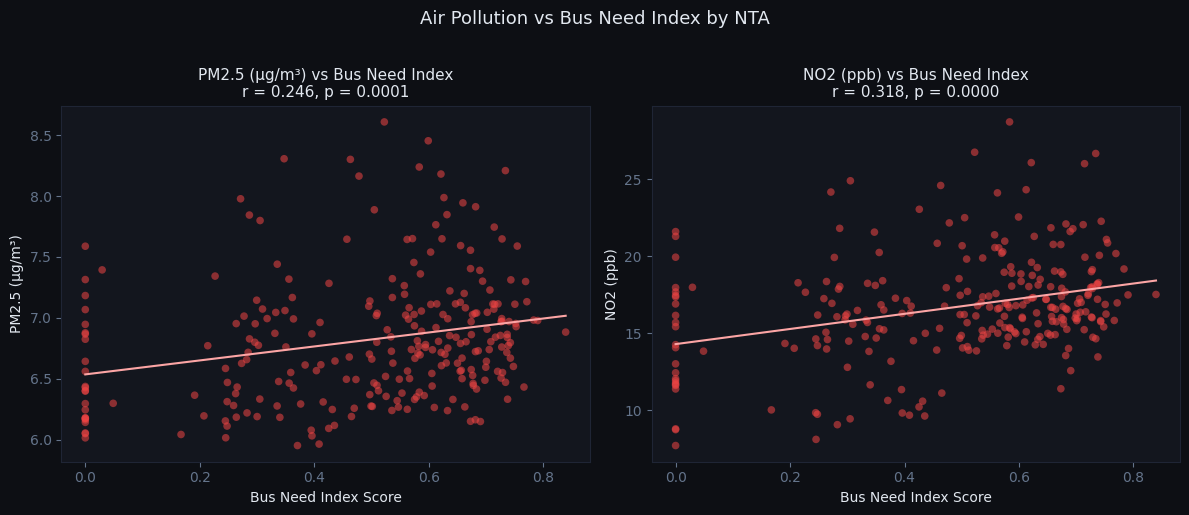

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.patch.set_facecolor('#0d0f14')

for ax, (col, label, r, p) in zip(axes, [
    ('PM_Avg',  'PM2.5 (µg/m³)', r_pm25, p_pm25),
    ('NO2_Avg', 'NO2 (ppb)',      r_no2,  p_no2)
]):
    ax.set_facecolor('#13161e')
    ax.scatter(
        combined['index_score'], combined[col],
        color='#ef4444', alpha=0.55, s=30, edgecolors='none'
    )

    m, b = np.polyfit(combined['index_score'], combined[col], 1)
    x_line = sorted(combined['index_score'])
    ax.plot(x_line, [m * x + b for x in x_line], color='#fca5a5', linewidth=1.5)

    ax.set_xlabel('Bus Need Index Score', color='#e2e8f0', fontsize=10)
    ax.set_ylabel(label, color='#e2e8f0', fontsize=10)
    ax.set_title(f'{label} vs Bus Need Index\nr = {r:.3f}, p = {p:.4f}',
                 color='#e2e8f0', fontsize=11)
    ax.tick_params(colors='#64748b')
    for spine in ax.spines.values():
        spine.set_edgecolor('#1f2535')

plt.suptitle('Air Pollution vs Bus Need Index by NTA', 
             color='#e2e8f0', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('air_pollution_correlation.png', dpi=150, bbox_inches='tight',
            facecolor='#0d0f14')
plt.show()

Neighborhoods that score highest on bus need are also the neighborhoods bearing the greater pollution burden. This means fare-free buses implemented there would serve the population with the most compounded disadvantage.